# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
#The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010,corresponding to a total of 79354 contacts. 

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
#Though there are no missing values for the outcome, some variables (like job, marital, education,default, housing, loan) have unknown categories.
#Additionally other variables like pdays also had missing values where pdays=999 meaning that the client was not previously contacted.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
#Business Objective:
#The objective is to help the Portuguese banking institution improve the effectiveness of its direct marketing campaigns 
#by predicting whether a client is likely to subscribe to a term deposit product. 
#By identifying customers with a higher probability of subscribing, the bank can target marketing efforts more efficiently,
#reduce campaign costs, improve conversion rates, and allocate resources more effectively.

#This is a supervised learning problem, specifically a binary classification task, 
#where the target variable (y) indicates whether a client subscribes to a term deposit (yes) or not (no).

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [39]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             f1_score, accuracy_score)

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate




In [9]:
#understanding the data
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Variables:")
print(cat_cols)

print("\nNumerical Variables:")
print(num_cols)

Categorical Variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

Numerical Variables:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [10]:
#data cleaning- replacing '999' by 'nan'
df['pdays'] = df['pdays'].replace(999, np.nan)
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,1515.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,6.014521,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,3.824906,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,3.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,6.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,7.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,27.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [11]:
#get the proportion of counts for categorical variables
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True) * 100)


job
job
admin.           25.303486
blue-collar      22.467709
technician       16.371273
services          9.636302
management        7.099155
retired           4.175974
entrepreneur      3.535010
self-employed     3.450034
housemaid         2.573565
unemployed        2.461882
student           2.124405
unknown           0.801204
Name: proportion, dtype: float64

marital
marital
married     60.522482
single      28.085850
divorced    11.197436
unknown      0.194231
Name: proportion, dtype: float64

education
education
university.degree      29.542585
high.school            23.101389
basic.9y               14.676605
professional.course    12.729436
basic.4y               10.138875
basic.6y                5.564728
unknown                 4.202680
illiterate              0.043702
Name: proportion, dtype: float64

default
default
no         79.120132
unknown    20.872584
yes         0.007284
Name: proportion, dtype: float64

housing
housing
yes        52.384190
no         45.212198
unknow

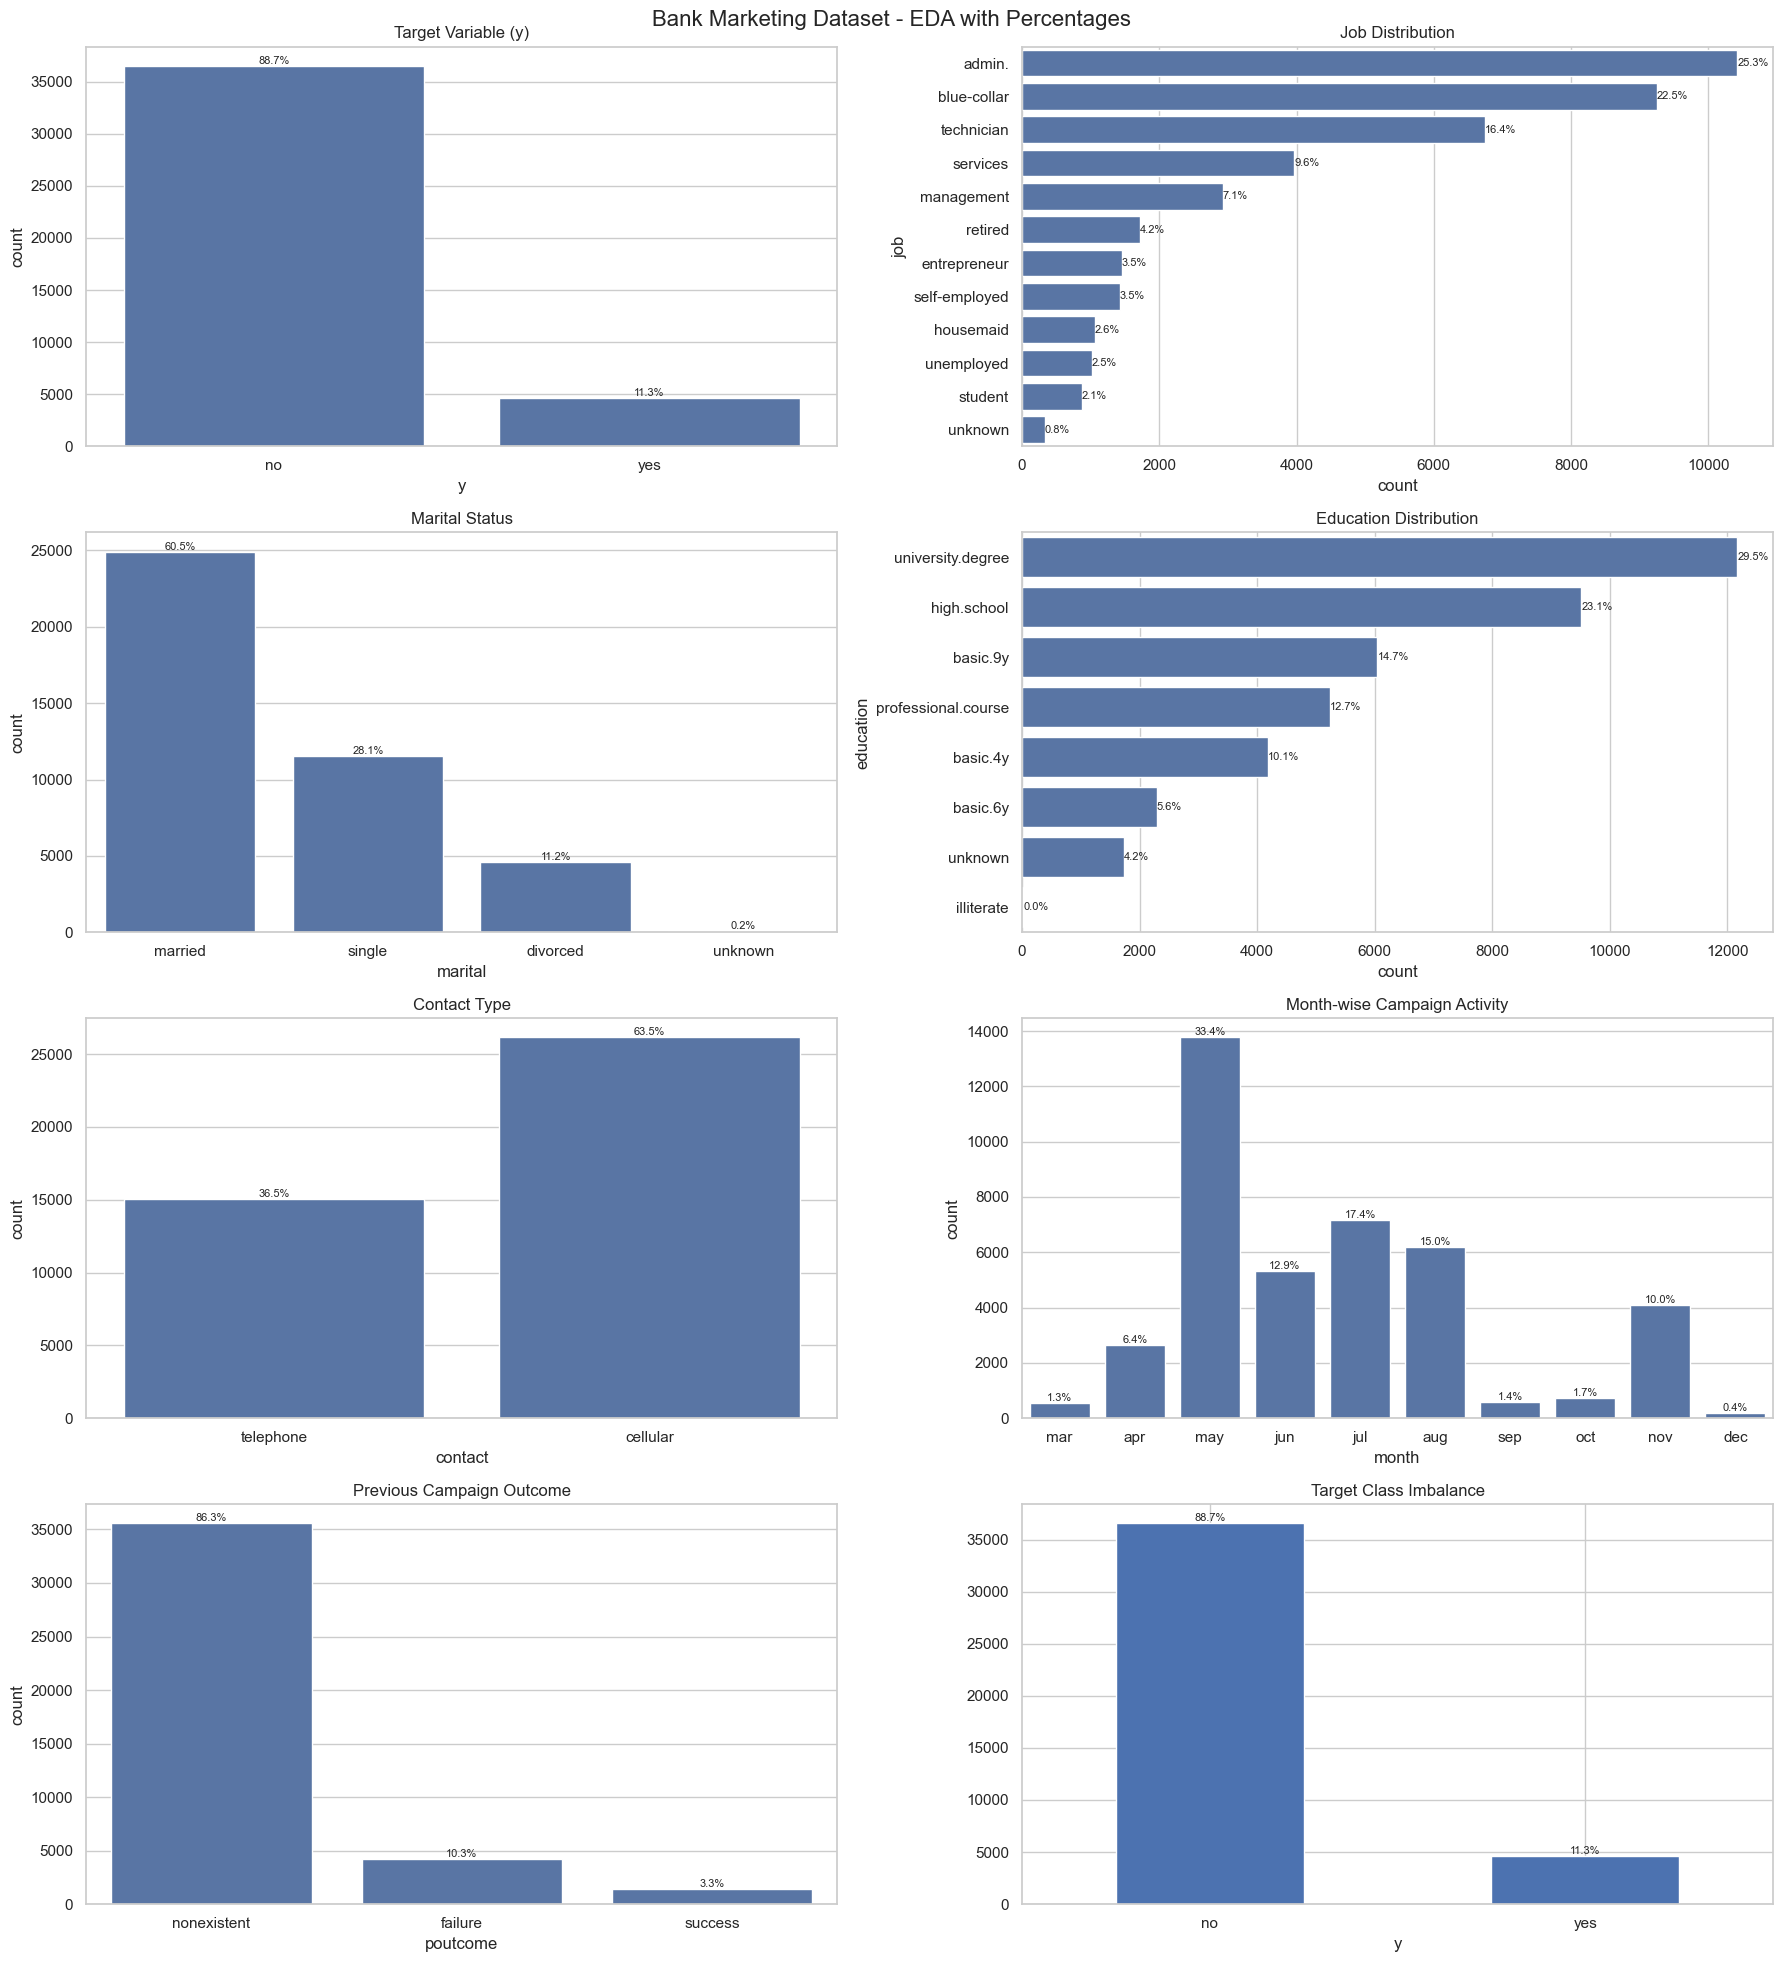

In [12]:

sns.set(style="whitegrid")

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
fig.suptitle("Bank Marketing Dataset - EDA with Percentages", fontsize=16)

total = len(df)

def add_percent(ax, total, orientation='vertical'):
    for p in ax.patches:
        if orientation == 'vertical':
            value = p.get_height()
            x = p.get_x() + p.get_width() / 2.
            y = value
            ha, va = 'center', 'bottom'
        else:
            value = p.get_width()
            x = value
            y = p.get_y() + p.get_height() / 2.
            ha, va = 'left', 'center'

        if value > 0:
            percent = (value / total) * 100
            ax.annotate(f'{percent:.1f}%', (x, y),
                        ha=ha, va=va, fontsize=8)

# 1. Target variable
sns.countplot(x='y', data=df, ax=axes[0, 0])
axes[0, 0].set_title("Target Variable (y)")
add_percent(axes[0, 0], total, orientation='vertical')

# 2. Job distribution
sns.countplot(y='job', data=df,
              order=df['job'].value_counts().index,
              ax=axes[0, 1])
axes[0, 1].set_title("Job Distribution")
add_percent(axes[0, 1], total, orientation='horizontal')

# 3. Marital status
sns.countplot(x='marital', data=df, ax=axes[1, 0])
axes[1, 0].set_title("Marital Status")
add_percent(axes[1, 0], total, orientation='vertical')

# 4. Education
sns.countplot(y='education', data=df,
              order=df['education'].value_counts().index,
              ax=axes[1, 1])
axes[1, 1].set_title("Education Distribution")
add_percent(axes[1, 1], total, orientation='horizontal')

# 5. Contact type
sns.countplot(x='contact', data=df, ax=axes[2, 0])
axes[2, 0].set_title("Contact Type")
add_percent(axes[2, 0], total, orientation='vertical')

# 6. Month distribution
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
sns.countplot(x='month', data=df, order=month_order, ax=axes[2, 1])
axes[2, 1].set_title("Month-wise Campaign Activity")
add_percent(axes[2, 1], total, orientation='vertical')

# 7. Previous outcome
sns.countplot(x='poutcome', data=df, ax=axes[3, 0])
axes[3, 0].set_title("Previous Campaign Outcome")
add_percent(axes[3, 0], total, orientation='vertical')

# 8. Target class imbalance
df['y'].value_counts().plot(kind='bar', ax=axes[3, 1])
axes[3, 1].set_title("Target Class Imbalance")
axes[3, 1].tick_params(axis='x', rotation=0)
for p in axes[3, 1].patches:
    value = p.get_height()
    if value > 0:
        percent = (value / total) * 100
        axes[3, 1].annotate(f'{percent:.1f}%',
                            (p.get_x() + p.get_width() / 2., value),
                            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# Exploratory data analysis findings
# Strong class imbalance: Only 11.27% “yes” subscriptions vs 88.73% “no”, making this a key modeling challenge.

# Common Characteristics
# Jobs: admin (25.30%), blue-collar (22.47%), technician (16.37%) → ~64% total
# Marital status: married (60.52%), single (28.09%), divorced (11.20%)
# Education: university degree (29.54%), high school (23.10%) → ~52% combined

# Financial attributes:
# Default: 79.12% no, 20.87% unknown, 0.007% yes
# Housing loan: 52.38% yes, 45.21% no
# Personal loan: 82.43% no, 15.17% yes

# Campaign behavior is skewed:
# Most clients contacted only a few times (campaign mean 2.57, median 2). Extreme outliers up to 56 contacts
# Contact duration is highly skewed (mean 258s, max 4918s) → potential leakage risk

# Strong seasonal effects:
# May alone accounts for 33.43% of contacts
# Jul–Aug–Jun combined form a large share, while winter months are minimal (<5% each)

# Contact method:
# Cellular: 63.47%
# Telephone: 36.53%

# Previous campaign history is sparse:
# 86.34% nonexistent
# 10.32% failure
# 3.33% success

# Macro-economic indicators matter:
# Euribor3m mean 3.62
# Employment variation rate mean 0.08
# Low variance but strong predictive signal

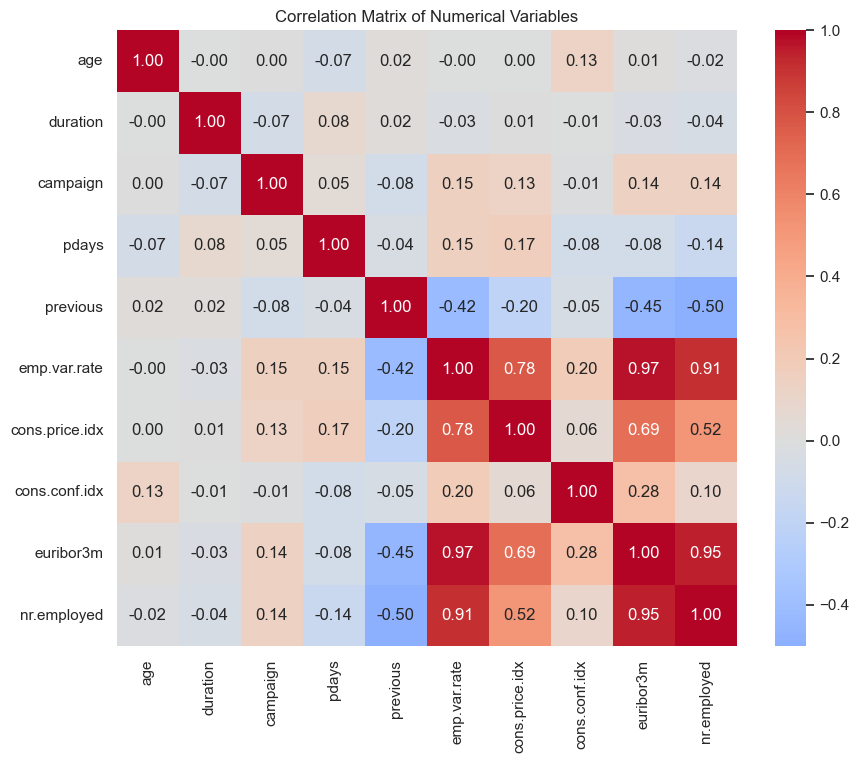

In [14]:
#compare the collinerity and its relation to outcome

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [15]:
#Correlation analysis revealed limited multicollinearity among most predictors. 
#However, strong positive correlations were observed between the macroeconomic variables emp.var.rate, euribor3m, and nr.employed (r = 0.91–0.97),indicating that these variables capture similar economic trends. 
#Apart from these indicators, correlations among the remaining features were generally weak, suggesting that most variables contribute unique information to the dataset.


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [22]:
#split dataset
X = df.drop('y', axis=1)
y = df['y']
y = df['y'].map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#check the split
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(32950, 20)
(8238, 20)
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


In [23]:
X_train.isnull().sum().sort_values(ascending=False)

for col in X_train.select_dtypes(include='object').columns:
    unknown_pct = (X_train[col] == 'unknown').mean() * 100
    print(f"{col}: {unknown_pct:.2f}%")

job: 0.80%
marital: 0.20%
education: 4.24%
default: 21.06%
housing: 2.42%
loan: 2.42%
contact: 0.00%
month: 0.00%
day_of_week: 0.00%
poutcome: 0.00%


In [24]:
#pre-processing 

num_cols=X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols=X_train.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

# Impute THEN scale for numeric
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Impute THEN encode for categorical
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Now fit_transform — imputation is handled inside
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Training shape: (32950, 63)
Testing shape: (8238, 63)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [25]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_processed, y_train)
y_pred_baseline = dummy.predict(X_test)

print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7310
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



/Users/shrutiparulekar/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shrutiparulekar/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shrutiparulekar/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

In [26]:
#The dummy majority-class classifier achieves 89% accuracy but completely fails on the positive class (recall = 0.00, F1 = 0.00). 
#This confirms class imbalance is a central modeling challenge. 
#Our target models (Logistic Regression, XGBoost) must meaningfully improve recall on the positive class while the macro F1 of 0.47 sets the floor to beat.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [38]:
#Logistic Regression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_test_processed)
y_prob_lr  = lr.predict_proba(X_test_processed)[:, 1]

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238



### Problem 9: Score the Model

What is the accuracy of your model?

In [ ]:
#The accuracy of the model is .87

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [ ]:
# Models with default parameters
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC()
}

# Define F1 scorer
#f1_scorer = make_scorer(f1_score, pos_label='yes')

results = []

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X_train_processed, y_train,
        cv=5,
        scoring=
            {'accuracy': 'accuracy',
            'f1': 'f1_macro'},
        return_train_score=False
    )
    
    results.append({
        "Model": name,
        "Mean Accuracy": cv_results['test_accuracy'].mean(),
        "Mean F1 Score": cv_results['test_f1'].mean(),
        "Fit Time (s)": cv_results['fit_time'].mean()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Mean Accuracy", ascending=False)

print(results_df)

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [28]:
#Logistic Regression

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_params,
    cv=5,
    scoring='f1_macro'
)

lr_grid.fit(X_train_processed, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV Score:", lr_grid.best_score_)

Best Parameters: {'C': 100}
Best CV Score: 0.7305994073487547


In [29]:
#kneighbors classifier

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring='f1_macro'
)

knn_grid.fit(X_train_processed, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV Score:", knn_grid.best_score_)

Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}
Best CV Score: 0.7064514096550504


In [30]:
#DecisionTreeClassifier

dt_params = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='f1_macro'
)

dt_grid.fit(X_train_processed, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV Score:", dt_grid.best_score_)


Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.7664225182784401


In [31]:
#SVC

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(
    SVC(),
    param_grid=svm_params,
    cv=5,
    scoring='f1_macro'
)

svm_grid.fit(X_train_processed, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV Score:", svm_grid.best_score_)

Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best CV Score: 0.7306924487980428


In [32]:
#summarzing the results of all models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Best Score': [
        lr_grid.best_score_,
        knn_grid.best_score_,
        dt_grid.best_score_,
        svm_grid.best_score_
    ],
    'Best Parameters': [
        lr_grid.best_params_,
        knn_grid.best_params_,
        dt_grid.best_params_,
        svm_grid.best_params_
    ]
})

results.sort_values('Best Score', ascending=False)

,Model,Best Score,Best Parameters
2,Decision Tree,0.766423,"{'max_depth': 3, 'min_samples_leaf': 1, 'min_s..."
3,SVM,0.730692,"{'C': 10, 'kernel': 'rbf'}"
0,Logistic Regression,0.730599,{'C': 100}
1,KNN,0.706451,"{'n_neighbors': 9, 'weights': 'distance'}"


In [33]:
#The dummy majority-class classifier achieved 89% accuracy and F1 score of .47 
#All the hyperparameter tuned models perform better on the F1 score metric as compared to the majority-class classifier.

#Hyperparameter tuning improved model performance compared to the baseline models. 
#Using GridSearchCV with F1-score as the evaluation metric, the Decision Tree model achieved the highest performance with an F1 score of 0.766. 
#The optimal configuration used a maximum depth of 3, indicating that a relatively simple tree was sufficient to capture the important patterns in the data while avoiding overfitting.

#The SVM and Logistic Regression models achieved similar F1 scores of 0.730 and 0.730, respectively, while KNN produced the lowest performance with an F1 score of 0.706. 
#Overall, the Decision Tree model was selected as the best-performing model because it provided the strongest balance between precision and recall on this imbalanced classification problem.



In [34]:
#Predicting the results for the best fit model

# ── 1. Instantiate with best params from GridSearch 
best_dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=1,
    min_samples_split=2,   
    random_state=42
)

# ── 2. Fit on training data 
best_dt.fit(X_train_processed, y_train)

# ── 3. Predict on test data 
y_pred = best_dt.predict(X_test_processed)
y_pred_proba = best_dt.predict_proba(X_test_processed)[:, 1]  # probability of positive class

# ── 4. Evaluate 
print("=" * 50)
print("DECISION TREE — TEST SET PERFORMANCE")
print("=" * 50)

print(f"\nAccuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Macro  : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")


print("\nResults on the Test Data")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("=" * 50)
print("DECISION TREE — TRAINING SET PERFORMANCE")
print("=" * 50)

y_train_pred = best_dt.predict(X_train_processed)
print(classification_report(y_train, y_train_pred))
print(confusion_matrix(y_train, y_train_pred))



DECISION TREE — TEST SET PERFORMANCE

Accuracy  : 0.9133
F1 Macro  : 0.7786
F1 Weighted: 0.9124

Results on the Test Data

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7310
           1       0.62      0.59      0.61       928

    accuracy                           0.91      8238
   macro avg       0.78      0.77      0.78      8238
weighted avg       0.91      0.91      0.91      8238


Confusion Matrix:
[[6975  335]
 [ 379  549]]
DECISION TREE — TRAINING SET PERFORMANCE
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     29238
           1       0.60      0.58      0.59      3712

    accuracy                           0.91     32950
   macro avg       0.77      0.76      0.77     32950
weighted avg       0.91      0.91      0.91     32950

[[27788  1450]
 [ 1575  2137]]


In [35]:
#Overall, the training and test metrics are virtually identical across every measure 
#(F1 Macro: 0.770 vs 0.779, accuracy: 0.913 vs 0.913) indicating there is no overfitting.

       feature_clean  importance
1           duration    0.531489
9        nr.employed    0.397428
7      cons.conf.idx    0.036452
62  poutcome_success    0.034631


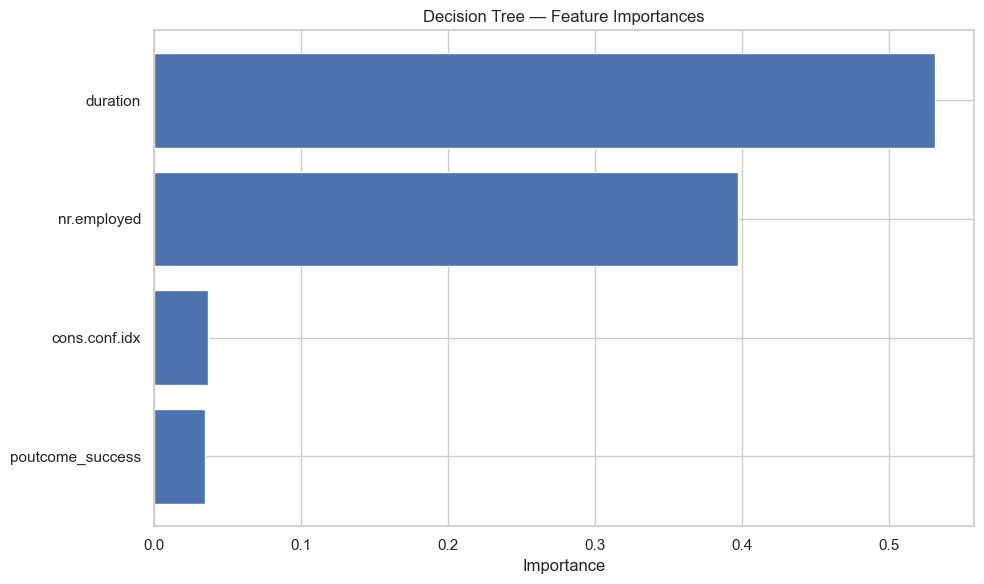

In [40]:
# Get feature importance
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_dt.feature_importances_ 
}).sort_values('importance', ascending=False)

feature_importance['feature_clean'] = (
    feature_importance['feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

print(feature_importance[feature_importance['importance'] > 0][['feature_clean', 'importance']])

# Plot
plt.figure(figsize=(10, 6))
feat = feature_importance[feature_importance['importance'] > 0]
plt.barh(feat['feature_clean'], feat['importance'])
plt.xlabel('Importance')
plt.title('Decision Tree — Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
#duration was the strongest predictor but is flagged as a leakage risk — it is only known after a call concludes and cannot inform pre-call decisions. It was retained here for benchmark purposes only and should be excluded from any production model.
#nr.employed, a quarterly macroeconomic indicator, was the strongest legitimate predictor, suggesting that broader economic conditions significantly influence a client's receptiveness to term deposit subscriptions.
#Notably, client-level demographic features (age, job, education, housing, loan) contributed zero importance, indicating that macro context and call behaviour dominate subscription outcomes in this shallow model.

In [ ]:
## Final Takeaways

# This analysis compared four classification models to predict term deposit subscriptions from direct marketing data. The tuned Decision Tree was 
# selected as the best-performing model, achieving an F1 Macro of 0.779 on the test set with no overfitting — train and test performance were virtually identical.

# Economic conditions, particularly the number of employees (`nr.employed`), emerged as the strongest legitimate predictor of subscription behaviour, outweighing individual customer demographics such as age, job, or education. 
# Customers who had subscribed in a previous campaign (`poutcome_success`) were also more likely to convert, making prior campaign history a valuable targeting signal.

# The model currently identifies approximately 6 in 10 likely subscribers. To improve this, use ensemble methods such as XGBoost, exclude the `duration` variable to eliminate leakage, and apply class-balancing techniques to better capture the minority class.